# A minimal working example of generating cryoEM particle stack and reconstructing with Ghostbuster


## Overview

### Particle stack generation

**1. Obtaining the atomic model.**
Download a biological assembly from the [RCSB PDB](https://www.rcsb.org/) by specifying its four-character accession code. SPECTER fetches the mmCIF assembly file and extracts atomic coordinates and element labels.

**2. Building the 3D scattering potential.**
The electrostatic potential of the specimen is assembled atom-by-atom using the Kirkland parameterisation of electron scattering factors (Kirkland, *Advanced Computing in Electron Microscopy*, 2nd ed., Springer, 2010). Each element's scattering factor is expressed as a sum of three Lorentzian and three Gaussian terms in reciprocal space:

$$f_e(s) = \sum_{i=1}^{3} \frac{a_i}{s^2 + b_i} + \sum_{i=1}^{3} c_i \, e^{-d_i s^2}$$

where $s = |\mathbf{q}|/2$ (in Å⁻¹) is the scattering parameter and $a_i, b_i, c_i, d_i$ are element-specific coefficients tabulated by Kirkland. The potential values are accumulated onto a 3-D voxel grid via soft voxelisation.

**3. Forward image model.**
Given the 3-D potential $V$, each 2-D projection image is produced by the following chain:

$$\underbrace{V}_{\text{3D potential}} \xrightarrow{\text{affine transform (rotation + shift)}} V' \xrightarrow{\text{scattering (multislice)}} \psi \xrightarrow{\text{CTF / aberrations}} \tilde{\psi} \xrightarrow{\text{detector}} I$$

- **Affine transform** — the volume is rotated and translated according to the particle's pose (quaternion + shift in Å).
- **Scattering** — wave propagation through the projected potential. The default mode is *multislice*, which is the most physically accurate. Faster approximations (*Rytov*, *first Born*, *projection*) are also available.
- **Transfer function** — applies the contrast transfer function (CTF) and optional holography aberrations (spherical aberration $C_s$, defocus, astigmatism, phase shift, trefoil, …) in Fourier space.
- **Detector** — models Poisson shot noise, coincidence loss (direct-electron detectors), and an optional detector MTF.

**4. Environment models.**
Two optional additions can make the simulated data more realistic:
- *Molecular crowding* — additional copies of the particle (or other species) are packed around the central particle at a configurable minimum separation distance.
- *Amorphous ice* — an ice volume is composited with the particle volume before scattering. Several algorithms are available: `random` is fastest (matches bulk ice density only), `ap` (alternating projection) is slower but captures short-range order, and `mcmc`/`gd` variants offer higher structural accuracy at greater computational cost.

**5. Normalisation and sign convention.**
By convention, most cryo-EM software (RELION, CryoSPARC, …) stores particles normalised to zero mean and unit standard deviation, with *bright particle on dark background* (i.e. particle density is positive). SPECTER's raw output has the opposite sign (high-density regions appear dark, as in the physical image), so after generation the particles are sign-flipped and standardised:

$$p = -\frac{I - \mu_I}{\sigma_I}$$

---

### Reconstruction with Ghostbuster

Ghostbuster solves the inverse problem: given a stack of normalised experimental (or simulated) images and their associated poses, recover the underlying 3-D scattering potential.

**Forward model in reverse via autograd.**
The same forward pipeline used for generation is embedded inside a differentiable PyTorch/Lightning module. The 3-D volume is treated as a learnable parameter; gradient descent minimises the discrepancy between the forward-modelled images and the observed images. No analytical back-projection is used — all gradients flow through the physics model.

**De-normalisation before reconstruction.**
Because reconstruction operates on physical intensities (electron counts), the normalisation applied during generation must be inverted before passing images to Ghostbuster:

$$I = -\sigma \cdot p + \mu$$

where $\mu$ and $\sigma$ are the per-stack mean and standard deviation saved at generation time.

**Symmetry.**
If the particle has point-group symmetry (e.g. octahedral `O`, icosahedral `I`), Ghostbuster applies symmetry averaging after each epoch. Importantly, the poses in the input stack must be expressed relative to the *symmetry-axis convention of RELION* — for example, RELION's `I1` icosahedral frame is equivalent to CryoSPARC's `I` frame. Mismatched conventions will produce smeared reconstructions.

**Scattering model for reconstruction.**
Reconstruction uses the *Rytov* approximation rather than full multislice. Rytov is significantly faster (important when running thousands of forward passes during optimisation) and is a higher-order approximation than the first-Born/projection approach, capturing multiple-scattering phase accumulation without the per-slice propagation cost of multislice.

In [ ]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
import lightning as L

from specter import rotations
from specter.ice import IceBank
from specter.image import normalize_particles
from specter.imagegenerator import ImageGenerator
from specter.pdb import PDB
from specter.plots import (
    plot3d,
    plot_particle_stack,
    VolumeMonitorCallback,
    plot_map_to_model_fsc,
)
from specter.potential import PotentialBuilder
from specter.progress import track
from specter.ghostbuster import Reconstructor
from specter.arrays import ball3d

%load_ext autoreload
%autoreload 2

## Create 3D scattering potential

In [2]:
# fetch pdb file
pdb_code = "7a4m"
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")
# pdb = PDB("../pdb-data/water_645_coords.pdb")

Assemblies available: 1
7a4m: Fetching default Biological Assembly 1
File already exists: ../pdb-data/7a4m-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
device = "cpu"
pb = PotentialBuilder(n, dx, pdb.atomic_numbers).to(device)

In [4]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Building element ...:   0%|          | 0/7 [00:00<?, ?it/s]

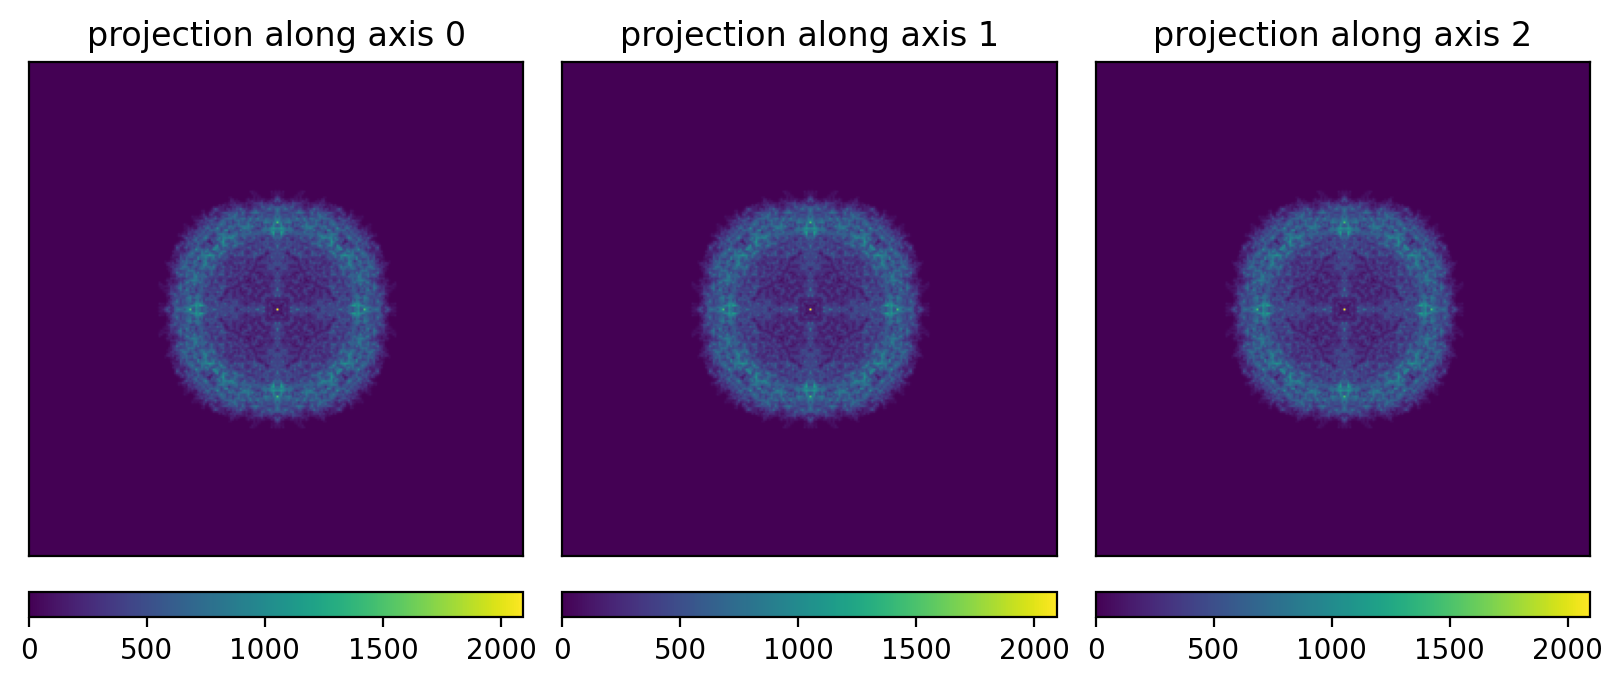

In [5]:
plot3d(V)

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [6]:
n_particles = 200
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
num_frames = int(dose_per_angstrom)  # usually ~ 1-2 e-/A^2/frame

In [7]:
# random quaternions
quaternions = rotations.random_quaternion(n_particles)
quaternions.shape

torch.Size([200, 4])

In [8]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_particles),
    "dfu": defocus_A,
}

In [9]:
# random shift. set to 0 for no shifts
shift = 2  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([200, 2])

In [10]:
device = "cuda:1"  # choose cpu if you run out of cuda memory.
device_id = 1  # match with device

In [ ]:
# Build the bank once — move to GPU before building
bank = IceBank(dx=dx, n=256, method="random", num_unique=1).to(device)
bank.build()

In [ ]:
# Scattering model: 'multislice', 'firstborn', 'projection', 'ctf'
scattering_model = "multislice"

# Aberration model: 'holography' or 'ctf'
aberration_model = "holography"

# Noise model: 'poisson' or None
noise_model = "poisson"
# noise_model = None

# Coincidence radius in angstroms.
# Higher values suppress lower spatial frequencies.
# Set to 0 to recover default Poisson behaviour.
coincidence_radius = 1.8 / dx

# Ice model:
#   'random' : fast, worst accuracy
#   'ap'     : alternating projection. moderate speed, low accuracy
#   'gd'     : gradient descent. slow, highest accuracy
#   'mcmc'   : monte carlo markov chain. slowest, medium accuracy, under development.
#   None     : disable ice
ice_model = "random"
# ice_model = None

ice_thickness = 0  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = None  # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = True

detector_model = None
# detector_model = "perfect"  # 'perfect', 'k3_300kv', 'k3_200kv'

model = ImageGenerator(
    V,
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    detector_model=detector_model,
    verbose=False,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
    icemaker=bank,
).to(device)

In [12]:
idx = torch.arange(n_particles)
images = []
batchsize = 5  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(range(0, n_particles, batchsize), description="Generating images"):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Generating images:   0%|          | 0/40 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/16 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/13 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/14 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/16 [00:00<?, ?it/s]

...

Applying coincidence loss:   0%|          | 0/20 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/20 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/20 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/20 [00:00<?, ?it/s]

torch.Size([200, 256, 256])

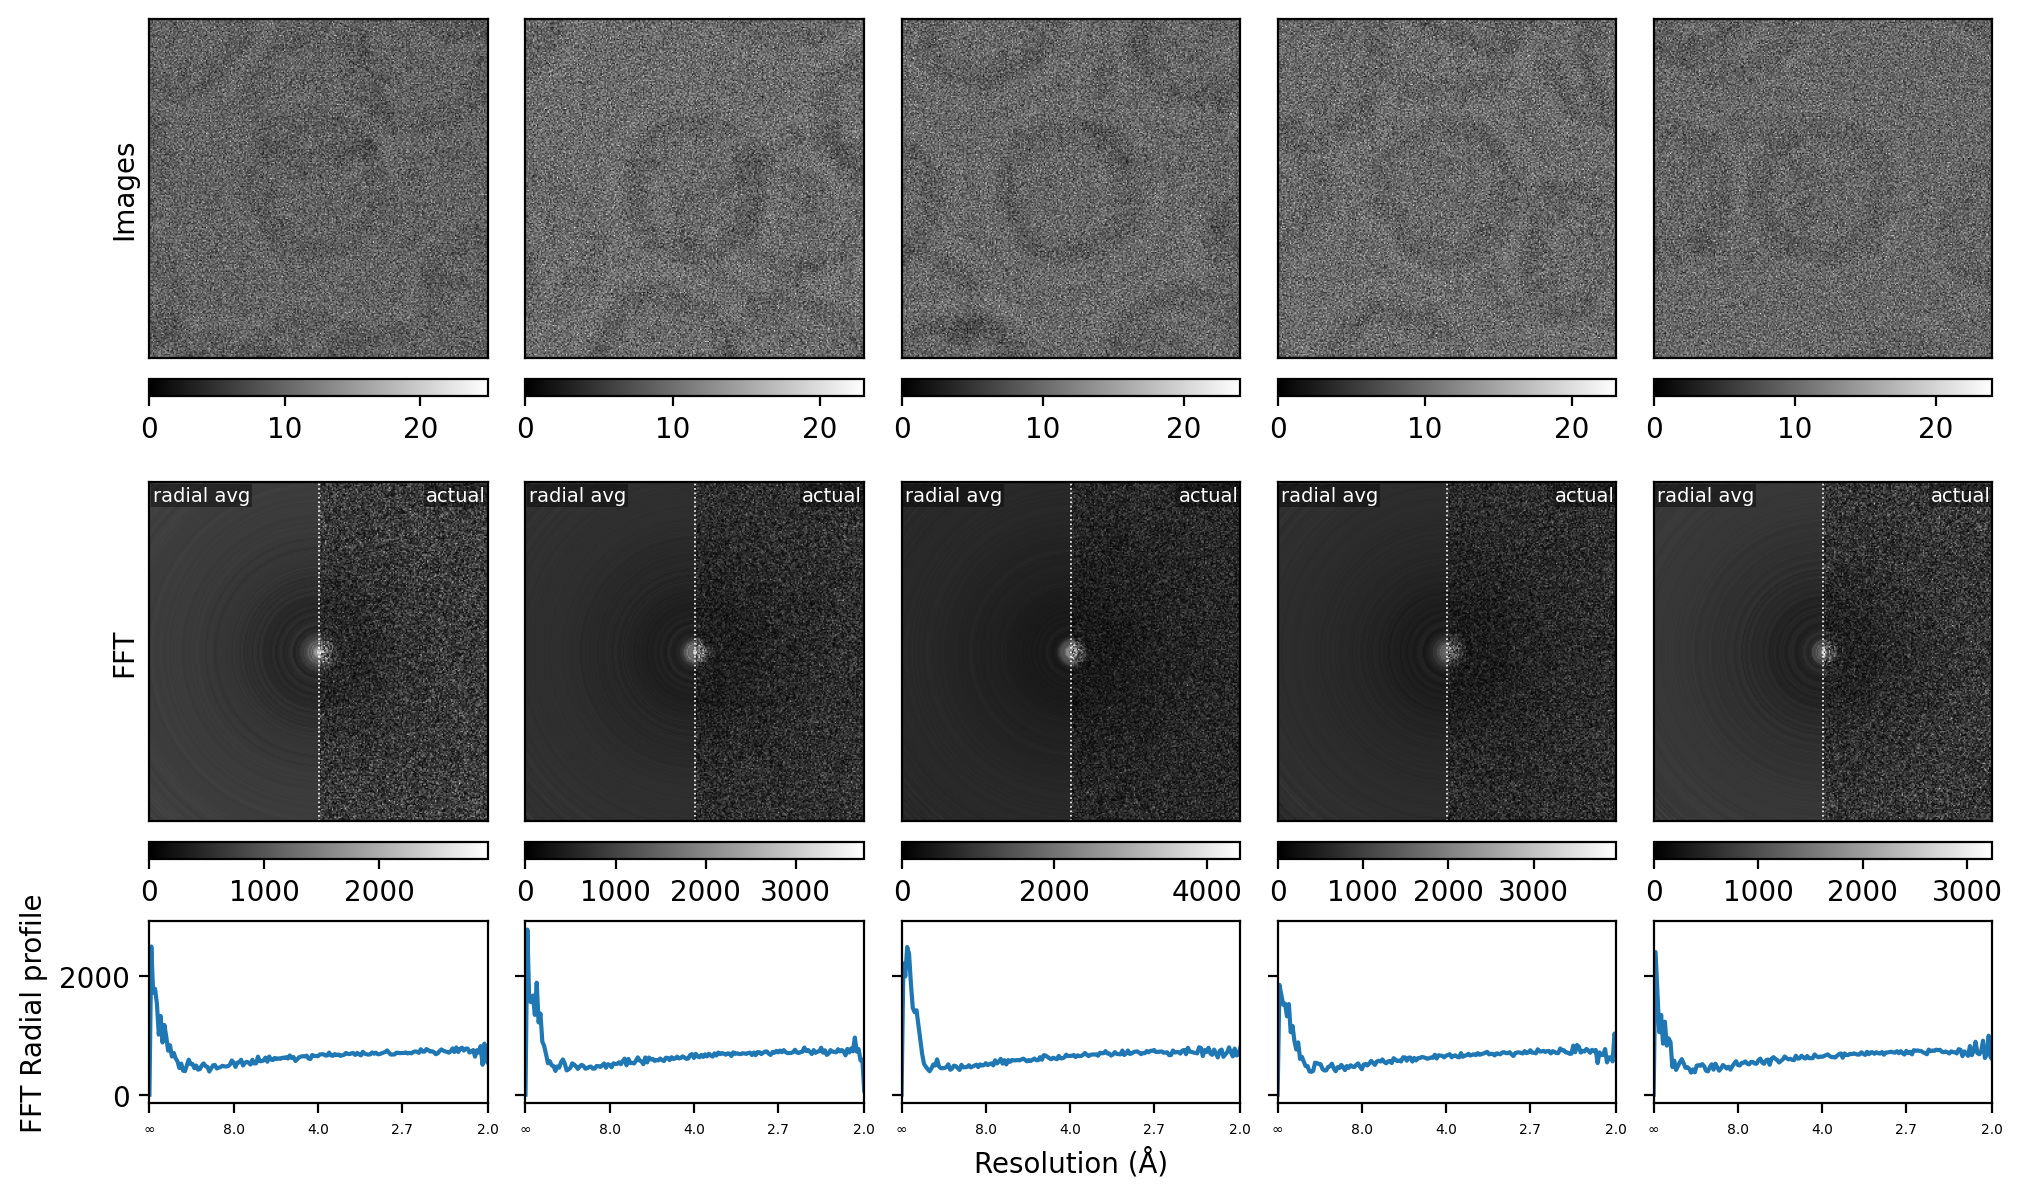

In [13]:
plot_particle_stack(images, pixel_size=dx)

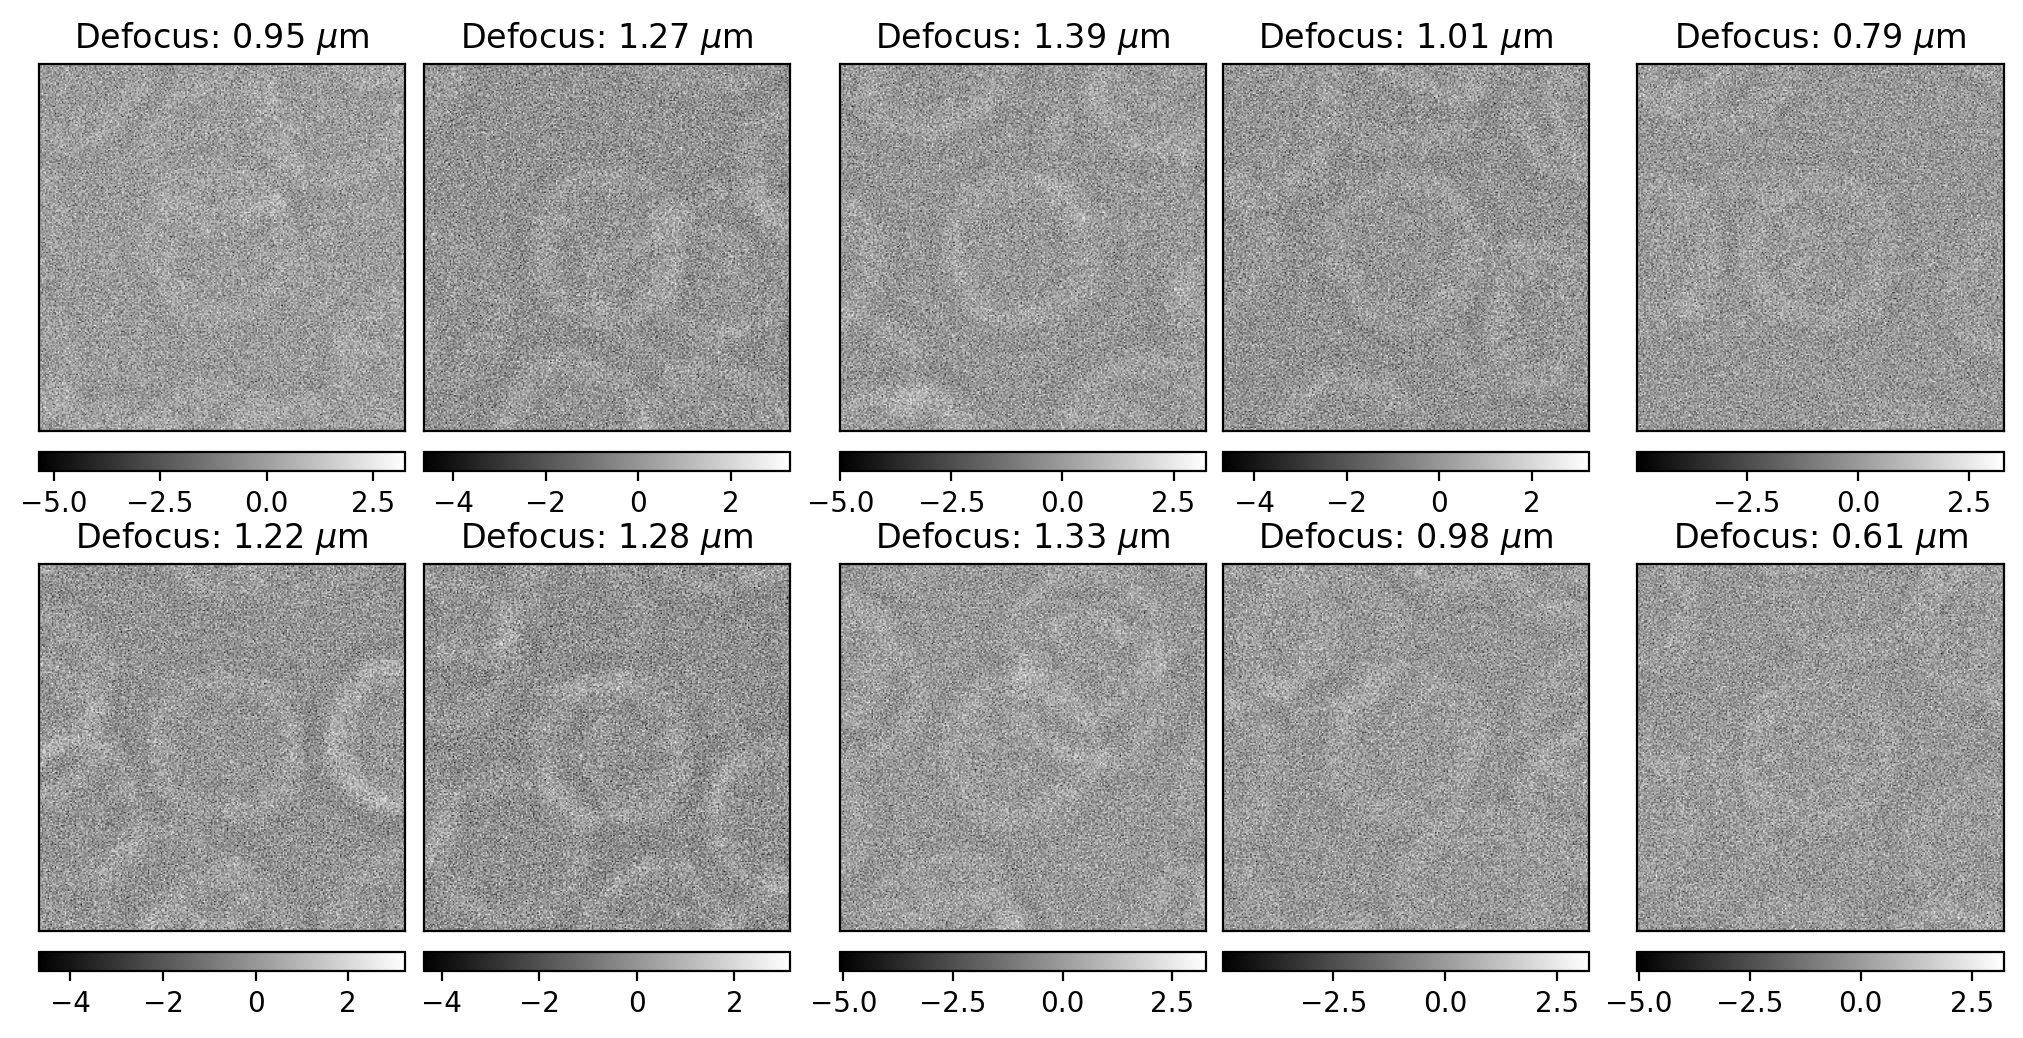

In [14]:
# normalize and flip sign
particles, means, stds = normalize_particles(images)
particles = -particles

fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(particles[i], cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params['dfu'][i] / 10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

## Reconstruct with Ghostbuster

In [15]:
scattering_model = "rytov"  # significantly faster than multislice
lr = 0.1
symmetry = "O"  # ensure pdb files are aligned to symmetry axes
niter = 5
batch_size = 3  # per iteration, change to fit gpu vram
symmetry_batchsize = (
    3  # set to smaller value if out of memory during symmetrizing after every epoch
)

In [16]:
# rescale images
dose_per_area = dose_per_angstrom * (dx) ** 2
images = -(dose_per_area**0.5) * particles + dose_per_area

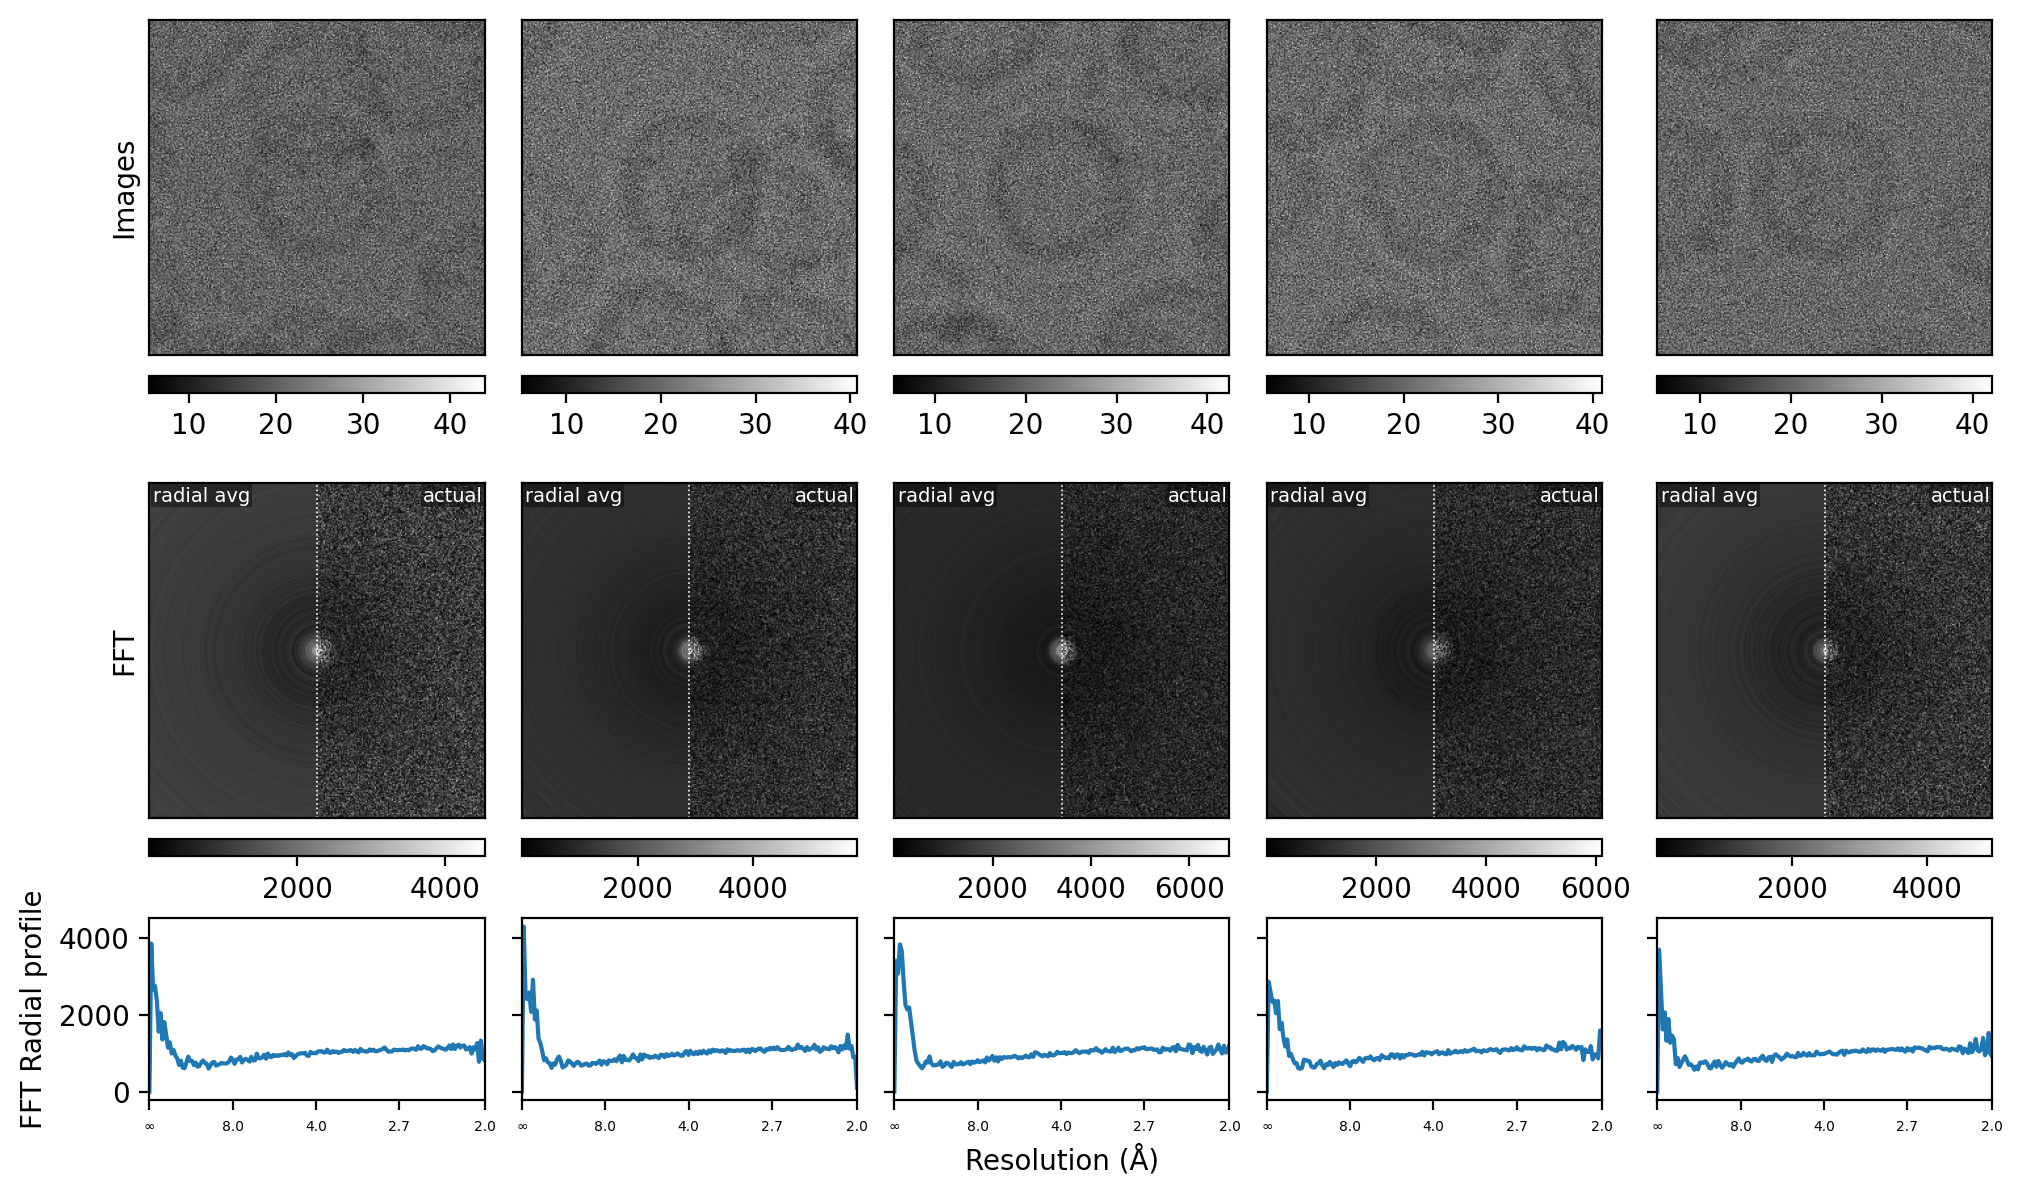

In [17]:
plot_particle_stack(images, pixel_size=dx)

In [18]:
volume_init = torch.zeros(images.shape[-1], images.shape[-1], images.shape[-1])

idx = torch.arange(n_particles)
training_dataset = TensorDataset(images.detach(), idx)
train_loader = DataLoader(training_dataset, batch_size=batch_size)
kmask = ball3d(images.shape[-1], images.shape[-1])  #  masks up to Nyquist shell

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Single parameter optimization mode.


Create first Born propagators:   0%|          | 0/256 [00:00<?, ?it/s]

You are using a CUDA device ('NVIDIA L40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/mnt/cbis/home/e0788253/czii/specter/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name           | Type           | Params | Mode 
----------------------------------------------------------
0 | imagegenerator | ImageGenerator | 0      | train
  | other params   | n/a            | 16.8 M | n/a  
----------------------------------------------------------
16.8 M    Trainable params
0         Non-trainable param

Training: |                                                                                                   …

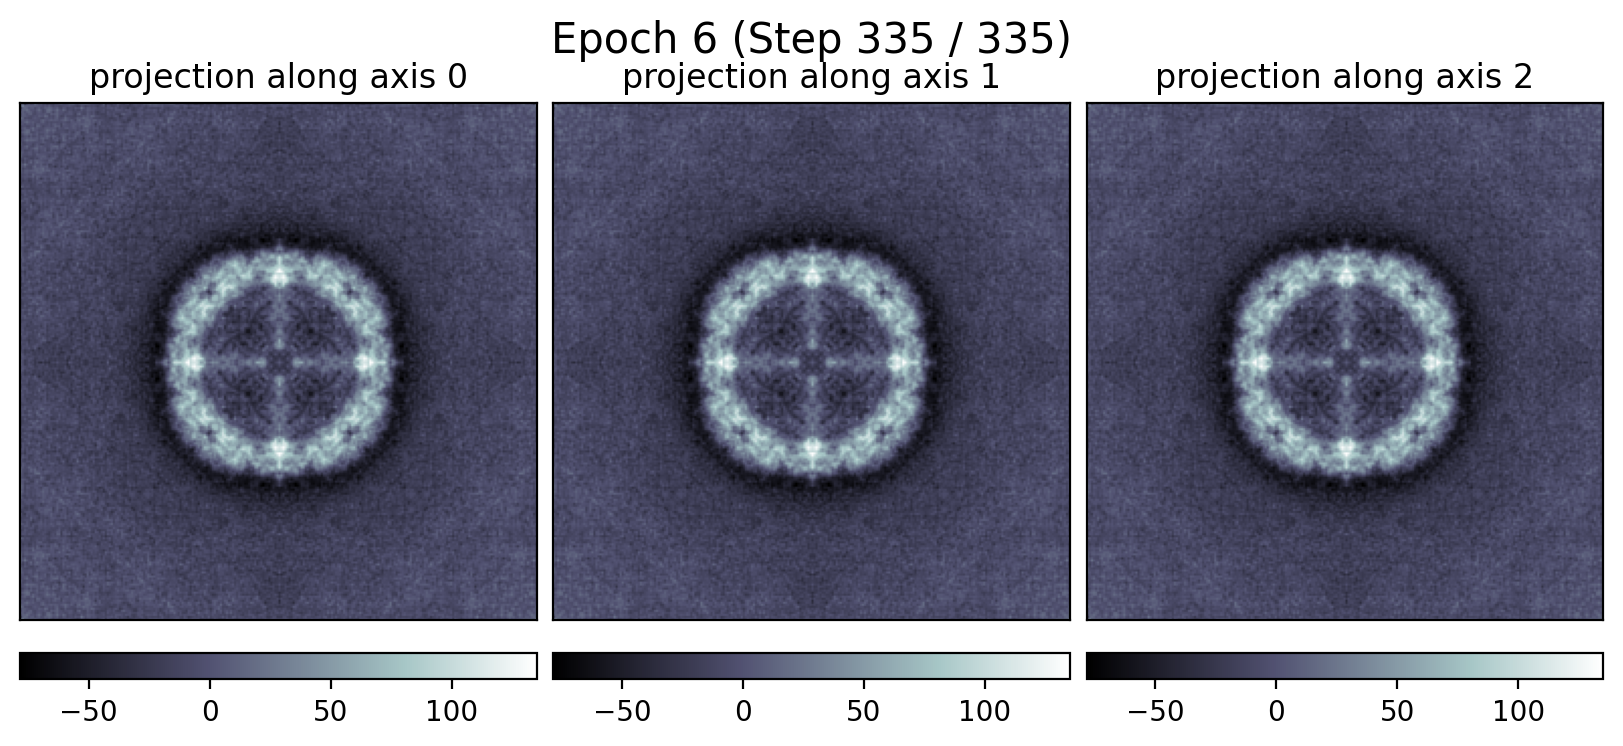

`Trainer.fit` stopped: `max_epochs=5` reached.


In [19]:
trainer = L.Trainer(
    accelerator="gpu",
    devices=[device_id],
    max_epochs=niter,
    precision="16-mixed",
    logger=False,
    enable_checkpointing=False,
    callbacks=[VolumeMonitorCallback(every_n_steps=100)],
)
model = Reconstructor(
    volume_init,
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    alpha=alpha,
    scattering_model=scattering_model,
    lr=lr,
    symmetry=symmetry,
    symmetry_batchsize=symmetry_batchsize,
    kmask=kmask,
)
trainer.fit(model, train_loader)

In [20]:
reconstructed_V = model.V.detach().cpu()

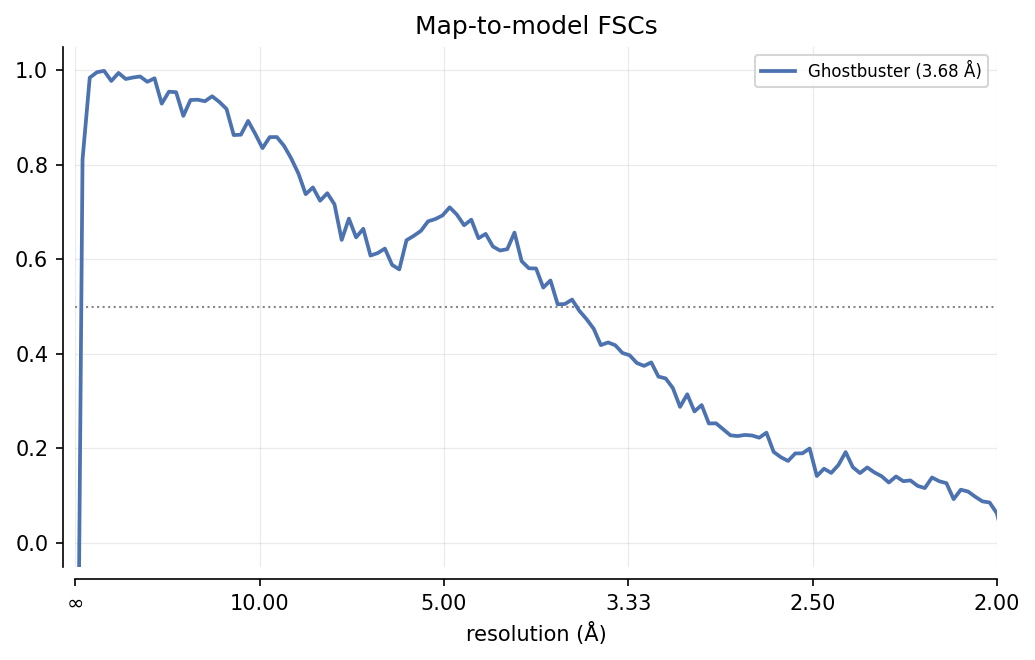

In [23]:
fig = plot_map_to_model_fsc(
    reconstructed_V, reference=V, voxel_size=dx, labels=["Ghostbuster"]
)